EMAIL SPAM DETECTION WITH MACHINE LEARNING

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Data Cleaning

In [3]:
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Dataset Information

In [4]:
print("Shape :", df.shape)
df.info()

Shape : (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Visualization

Spam vs Ham Distribution

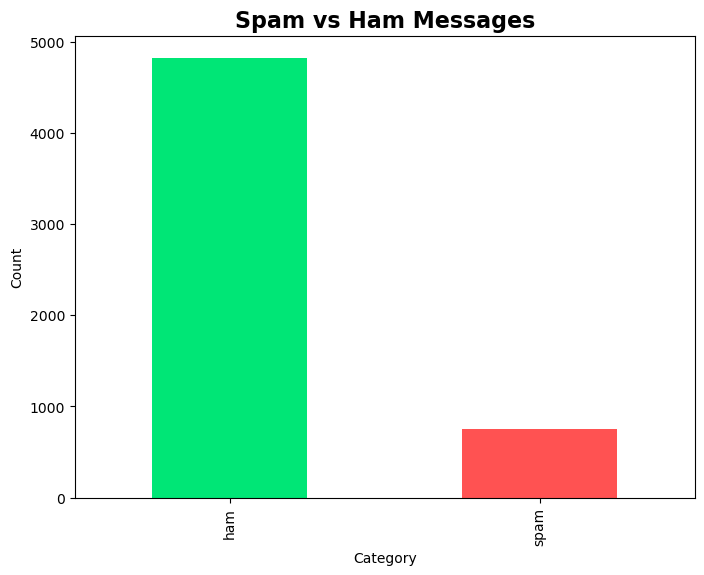

In [5]:
plt.figure(figsize=(8,6))

colors = ["#00E676", "#FF5252"]

df['label'].value_counts().plot(
    kind='bar',
    color=colors
)

plt.title("Spam vs Ham Messages", fontsize=16, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

Text Preprocessing

In [6]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text
df['message'] = df['message'].apply(clean_text)

Message Length Distribution

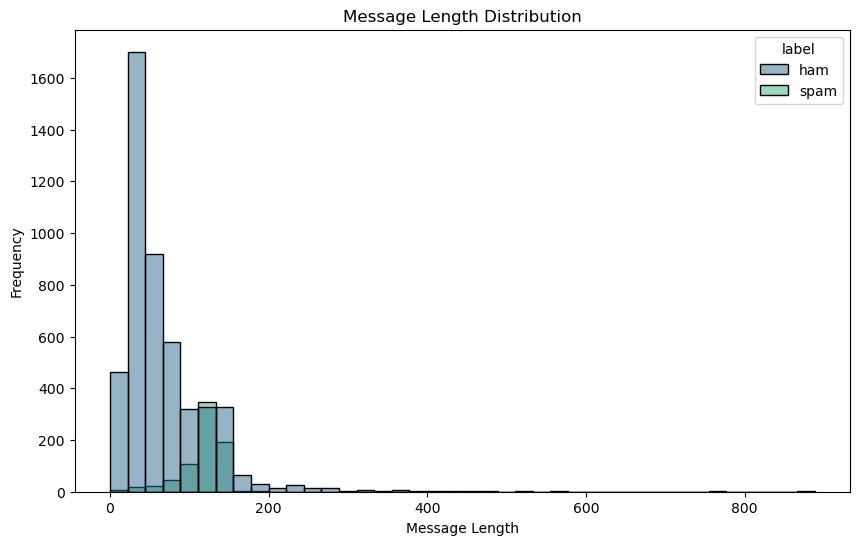

In [7]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=40,
    palette='viridis'
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

Convert Labels

In [8]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

TF-IDF Vectorization

In [9]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['message'])

y = df['label']

Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [11]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Prediction

In [12]:
y_pred = model.predict(X_test)

Accuracy

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :",
      round(accuracy*100,2),
      "%")

Accuracy : 97.04 %


Classification Report

In [14]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.78      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



Confusion Matrix

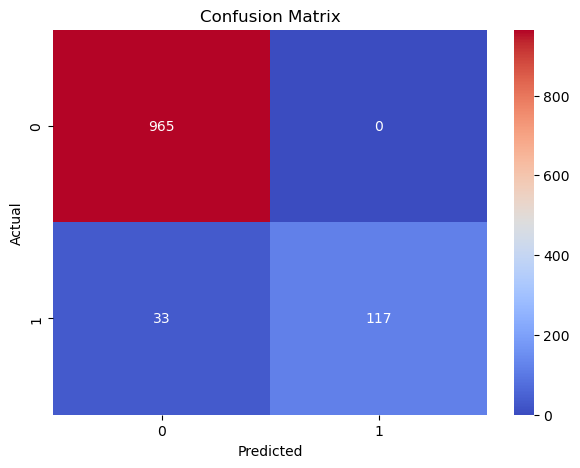

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Custom Spam Detection

In [16]:
sample_email = [
    "Congratulations! You won a free iPhone. Click here now."
]

sample_vector = tfidf.transform(sample_email)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("SPAM EMAIL")
else:
    print("HAM EMAIL")

SPAM EMAIL
